In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette("Set2")

# Leer los datos

In [2]:
df_fe = pd.read_csv("../../../data/respuestas_fede.csv")
print("Shape of data: ", df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
fig_name_prefix = 'youtube'
file_ext = '.png'
dpi_value = 200
include_title = True

Shape of data:  (369, 22)


## ¿Dónde se almacenan los videos que están en YouTube? 

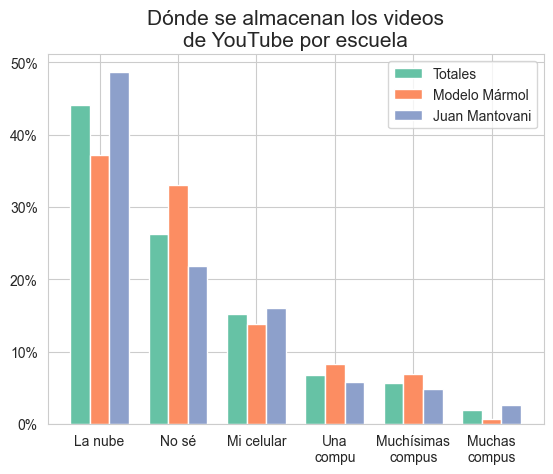

In [3]:
# ¿Dónde se almacenan los videos que están en YouTube? 
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1, result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2, result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3, result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Dónde se almacenan los videos\nde YouTube por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En ambos vemos las respuestas la nube y no sé como las más elegidas.
* Menos de un 10% elige la opción sin misconception, si sumamos no sé si llegamos a un 40% sin misc. en el Modelo Mármol y un 30% en el Mantovani. -> Este análisis debería estar a parte en otros gráficos creo.

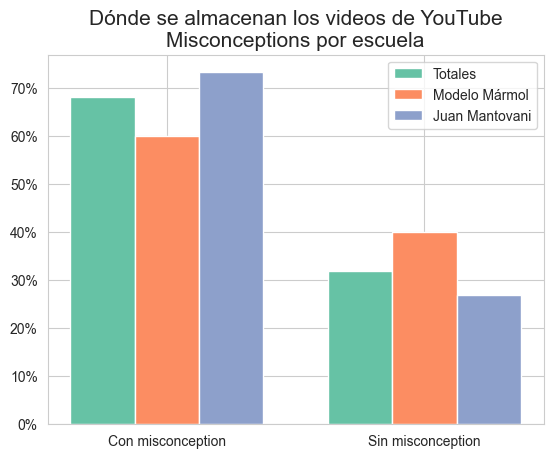

In [4]:
# Con misconception vs Sin Misconception - Agrega el No sé como sin misco - ¿Dónde se almacenan los videos que están en YouTube?
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\ncompus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True)
result = result.rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1, result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2, result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3, result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Dónde se almacenan los videos de YouTube\nMisconceptions por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_agregadas_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Cerca de un 70% presenta misconceptions en promedio. Estos son alumnos que no eligen "No sé" ni "Muchisimas computadoras"
* En el modelo mármol estamos cerca del 60%
* En el Mantovani por encima del 70%

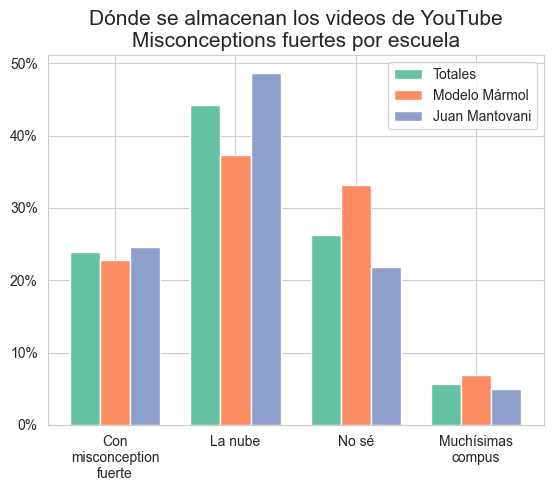

In [5]:
# Con misconception vs Sin Misconception - Desagrega el No sé y misco débil/fuerte - ¿Dónde se almacenan los videos que están en YouTube?
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'La nube') & 
                        (result.index != 'No sé') & 
                        (result.index != 'Muchísimas\ncompus')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='La nube'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "La nube",
                                2: "No sé",
                                3: "Muchísimas\ncompus"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("Dónde se almacenan los videos de YouTube\nMisconceptions fuertes por escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En este grafico desagregamos las "misconceptions fuertes" (Mi celular, Una computadora, Muchas compus) de las debiles (La nube), y las respuestas sin misconception (No se, Muchisimas compus)
* Podemos ver que la misconception mas significativa es "la nube" que no es misconception fuerte. En cuanto a las respuestas sin misconception, "No sé" es la mas significativa.
* Conclusion: hay tendencia a una misconception debil en torno a dónde se guardan los videos en YouTube.

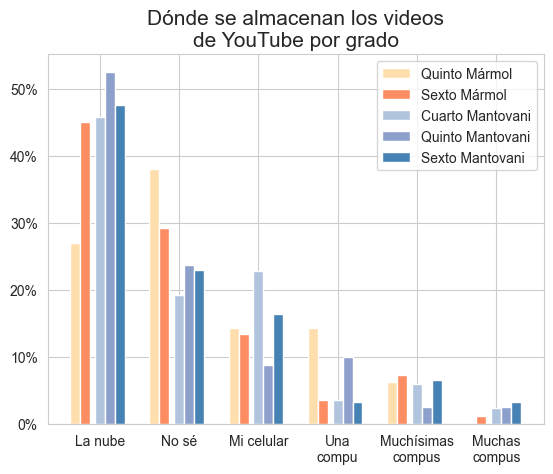

In [6]:
# ¿Dónde se almacenan los videos que están en YouTube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                        index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

result = result.reindex(["La nube",
                         "No sé",
                         "Mi celular",
                         "Una\ncompu",
                         "Muchísimas\ncompus",
                         "Muchas\ncompus"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("Dónde se almacenan los videos\nde YouTube por grado", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')

plt.savefig(fig_name_prefix + '_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Modelo Mármol: La nube es un 10% más elegida de 5to a 6to. No sé y una Compu un 10% menos elegida de 4to a 5to.
* Mantovani: Mi celular varía entre 4to a 6to.


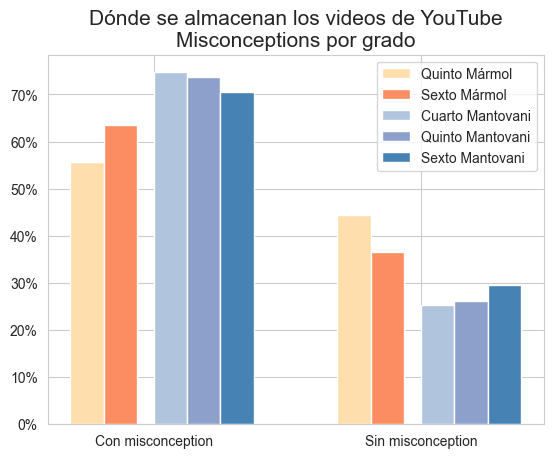

In [7]:
# Con misconception vs Sin Misconception - Agrega el No sé como sin misco - ¿Dónde se almacenan los videos que están en YouTube? - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\ncompus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True)
result = result.rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = [1, 3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']   , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']    , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'], width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'], width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani'] , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("Dónde se almacenan los videos de YouTube\nMisconceptions por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_agregadas_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)


* En el Modelo marmol contestan con mas misconceptions en grados mas altos
* En el Mantovani bajan levemente el porcentaje de misconceptions

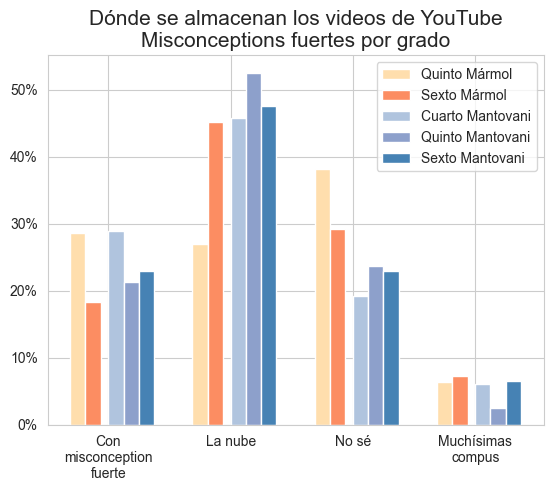

In [8]:
# Con misconception vs Sin Misconception - Desagrega el No sé y misco débil/fuerte - ¿Dónde se almacenan los videos que están en YouTube? - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'La nube') & 
                        (result.index != 'No sé') & 
                        (result.index != 'Muchísimas\ncompus')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='La nube'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "La nube",
                                2: "No sé",
                                3: "Muchísimas\ncompus"}).transpose()

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']   , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']    , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'], width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'], width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani'] , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("Dónde se almacenan los videos de YouTube\nMisconceptions fuertes por grado", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Si bien en el marmol aumentan en misconception de 5to a 6to, bajan mucho el % de misconception fuerte y responden más "la nube". Sin embargo tambien responden menos "No se" en favor de esta respuesta, cambiando una "no miscon" por una sí.
* En el Mantovani tambien responden menos con una misconception fuerte y también suben la respuesta "la nube". Sin embargo, aumentan levemente respuestas sin misconception: "No se" y "Muchisimas compus"

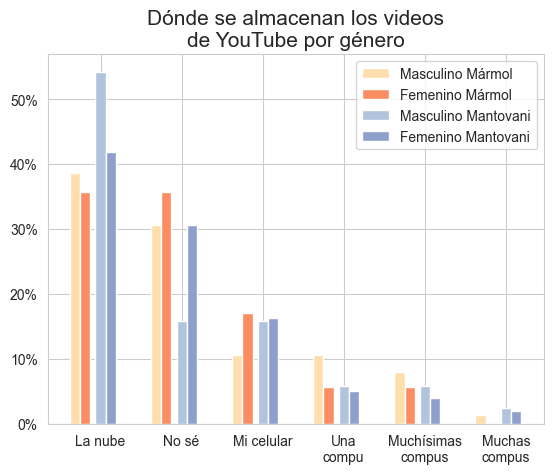

In [9]:
# ¿Dónde se almacenan los videos que están en YouTube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

result = result.reindex(["La nube", 
                         "No sé",
                         "Mi celular", 
                         "Una\ncompu",
                         "Muchísimas\ncompus",
                         "Muchas\ncompus"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("Dónde se almacenan los videos\nde YouTube por género", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')

plt.savefig(fig_name_prefix + '_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Mármol: No hay diferencias notorias.
* Mantovani: un 10% más de los varones eligen la opción de La nube. Un 15 % más de las mujeres eligen No se.

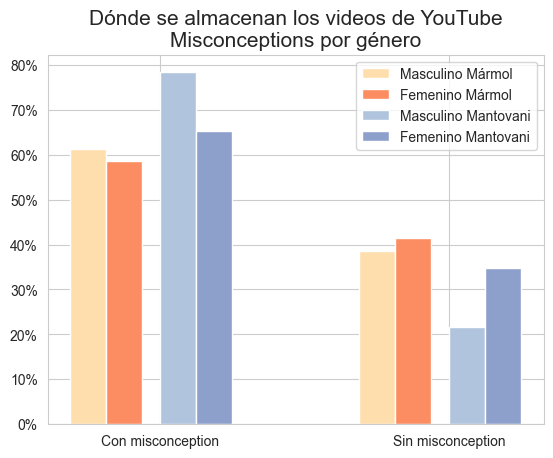

In [10]:
# Con misconception vs Sin Misconception - Agrega el No sé como sin misco - ¿Dónde se almacenan los videos que están en YouTube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\ncompus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\ncompus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con misconception", 1: "Sin misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("Dónde se almacenan los videos de YouTube\nMisconceptions por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_agregadas_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* No hay grandes diferencias en el Mármol
* En el Mantovani, los varones contestan con un 10% más de misconceptions

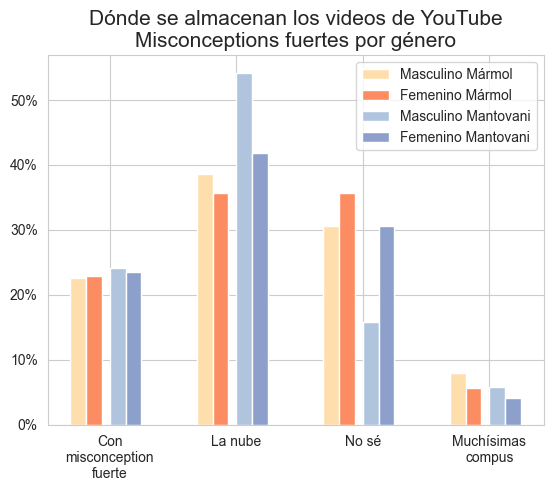

In [11]:
# Con misconception vs Sin Misconception - Desagrega el No sé y misco débil/fuerte - ¿Dónde se almacenan los videos que están en YouTube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\ncompu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\ncompus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\ncompus"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'La nube') & 
                        (result.index != 'No sé') & 
                        (result.index != 'Muchísimas\ncompus')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='La nube'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\ncompus'].sum(),
                     ], axis=1, ignore_index=True)

result = result.rename(columns={0: "Con\nmisconception\nfuerte",
                                1: "La nube",
                                2: "No sé",
                                3: "Muchísimas\ncompus"}).transpose()

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
      plt.title("Dónde se almacenan los videos de YouTube\nMisconceptions fuertes por género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_misco_desagregadas_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* En el Mármol no hay mucha diferencia con el género
* En el Mantovani los varones responden un 10% mas con la misconception debil "la nube" y las mujeres un 15% mas con la respuesta sin misconception "no se"

# Análisis estadístico

In [23]:
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import chi2_contingency
import textwrap

def calcular_intervalos_confianza(series, alpha=0.05, orden_respuestas=None):
    """Calcula proporciones e intervalos de confianza (Wilson) por categoría."""
    n = len(series)
    counts = series.value_counts()

    if orden_respuestas is None:
        categorias = list(counts.index)
    else:
        categorias = list(orden_respuestas)

    rows = []
    for cat in categorias:
        count = int(counts.get(cat, 0))
        prop = count / n if n > 0 else 0.0
        ci_low, ci_high = proportion_confint(count, n, alpha=alpha, method='wilson') if n > 0 else (0.0, 0.0)
        rows.append({
            'Respuesta': cat,
            'n': count,
            'proporcion': prop,
            'ci_low': ci_low,
            'ci_high': ci_high
        })

    return pd.DataFrame(rows)

def tabla_intervalos_confianza(df_plot):
    """Devuelve tabla resumen con formato legible para comparar con la salida anterior."""
    df_tabla = df_plot.copy()
    df_tabla['Proporción'] = df_tabla['proporcion'].map(lambda x: f"{x:.1%}")
    df_tabla['IC 95% inferior'] = df_tabla['ci_low'].map(lambda x: f"{x:.1%}")
    df_tabla['IC 95% superior'] = df_tabla['ci_high'].map(lambda x: f"{x:.1%}")
    df_tabla['Margen de error'] = ((df_tabla['ci_high'] - df_tabla['ci_low']) / 2).map(lambda x: f"±{x:.1%}")
    return df_tabla[['Grupo', 'Respuesta', 'n', 'Proporción', 'IC 95% inferior', 'IC 95% superior', 'Margen de error']]

def _formatear_respuesta_etiqueta(texto, ancho=46):
    """Agrega saltos de linea para mejorar legibilidad en etiquetas largas."""
    return textwrap.fill(str(texto), width=ancho, break_long_words=False)

def graficar_intervalos_confianza_por_grupo(series_por_grupo, titulo, alpha=0.05, mostrar_tabla=True, archivo_salida=None):
    """Grafica IC 95% por respuesta para multiples grupos y permite ver solapamientos."""
    orden_respuestas = []
    for serie in series_por_grupo.values():
        for valor in serie.dropna().value_counts().index:
            if valor not in orden_respuestas:
                orden_respuestas.append(valor)

    resultados = []
    for grupo, serie in series_por_grupo.items():
        df_ic = calcular_intervalos_confianza(serie, alpha=alpha, orden_respuestas=orden_respuestas)
        df_ic['Grupo'] = grupo
        resultados.append(df_ic)

    if not resultados:
        return pd.DataFrame()

    df_plot = pd.concat(resultados, ignore_index=True)

    grupos = list(series_por_grupo.keys())
    n_resp = len(orden_respuestas)
    y_base = np.arange(n_resp)

    # Offset dinamico por respuesta: centra los IC visibles sobre cada etiqueta.
    offset_map = {}
    for i, respuesta in enumerate(orden_respuestas):
        presentes = [
            g for g in grupos
            if float(df_plot[(df_plot['Grupo'] == g) & (df_plot['Respuesta'] == respuesta)]['n'].iloc[0]) > 0
        ]
        n_presentes = len(presentes)
        if n_presentes == 1:
            offsets = np.array([0.0])
        else:
            offsets = np.linspace(-0.22, 0.22, n_presentes)
        for g, off in zip(presentes, offsets):
            offset_map[(respuesta, g)] = off

    fig_height = max(5, 0.85 * n_resp + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_height))

    for grupo in grupos:
        data_g = df_plot[df_plot['Grupo'] == grupo].set_index('Respuesta').loc[orden_respuestas]

        x_vals = []
        y_vals = []
        xerr_low = []
        xerr_high = []
        for i, respuesta in enumerate(orden_respuestas):
            fila = data_g.loc[respuesta]
            if fila['n'] <= 0 or (respuesta, grupo) not in offset_map:
                continue

            x = float(fila['proporcion'])
            x_vals.append(x)
            y_vals.append(i + offset_map[(respuesta, grupo)])
            xerr_low.append(x - float(fila['ci_low']))
            xerr_high.append(float(fila['ci_high']) - x)

        if len(x_vals) == 0:
            continue

        ax.errorbar(
            x_vals,
            y_vals,
            xerr=np.vstack([xerr_low, xerr_high]),
            fmt='o',
            capsize=4,
            elinewidth=1.8,
            markersize=6,
            label=f"{grupo} (n={len(series_por_grupo[grupo])})"
        )

    y_labels = [_formatear_respuesta_etiqueta(r) for r in orden_respuestas]
    ax.set_yticks(y_base)
    ax.set_yticklabels(y_labels)
    ax.xaxis.set_major_formatter(PercentFormatter(1))

    # Recorta el espacio en blanco a la derecha usando el IC maximo observado + margen.
    x_max = float(df_plot['ci_high'].max()) + 0.03
    x_max = min(1.0, max(0.15, float(np.ceil(x_max / 0.05) * 0.05)))
    ax.set_xlim(0, x_max)

    ax.set_xlabel('Proporción')
    ax.set_ylabel('Respuesta')
    ax.set_title(titulo)
    ax.grid(axis='x', alpha=0.25)
    ax.legend()
    plt.tight_layout()

    if archivo_salida is not None:
        plt.savefig(archivo_salida, bbox_inches='tight', dpi=dpi_value)

    plt.show()

    if mostrar_tabla:
        display(tabla_intervalos_confianza(df_plot))

    return df_plot

def test_chi2_y_cramers_v(df, col_grupo, col_respuesta, nombre_comparacion):
    """Realiza test de chi-cuadrado y calcula Cramér's V entre dos o más grupos."""
    contingency = pd.crosstab(df[col_grupo], df[col_respuesta])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    k = min(contingency.shape)
    v = np.sqrt(chi2 / (n * (k - 1)))

    print(f"\n{'='*60}")
    print(f"Test Chi-cuadrado: {nombre_comparacion}")
    print(f"{'='*60}")
    print(f"\nTabla de contingencia:")
    display(contingency)
    print(f"\nχ² = {chi2:.4f},  p-valor = {p:.4f},  gl = {dof}")
    print(f"Cramér's V = {v:.4f}")

    if p < 0.05:
        print(f"\n✓ La diferencia ES estadísticamente significativa (p < 0.05)")
    else:
        print(f"\n✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)")

    if v < 0.1:
        efecto = "despreciable (V < 0.1)"
    elif v < 0.3:
        efecto = "pequeño (0.1 ≤ V < 0.3)"
    elif v < 0.5:
        efecto = "mediano (0.3 ≤ V < 0.5)"
    else:
        efecto = "grande (V ≥ 0.5)"
    print(f"Tamaño del efecto: {efecto}")

    return chi2, p, v

## Intervalos de confianza y test de chi-cuadrado: por escuela

INTERVALOS DE CONFIANZA (95%) - Por escuela


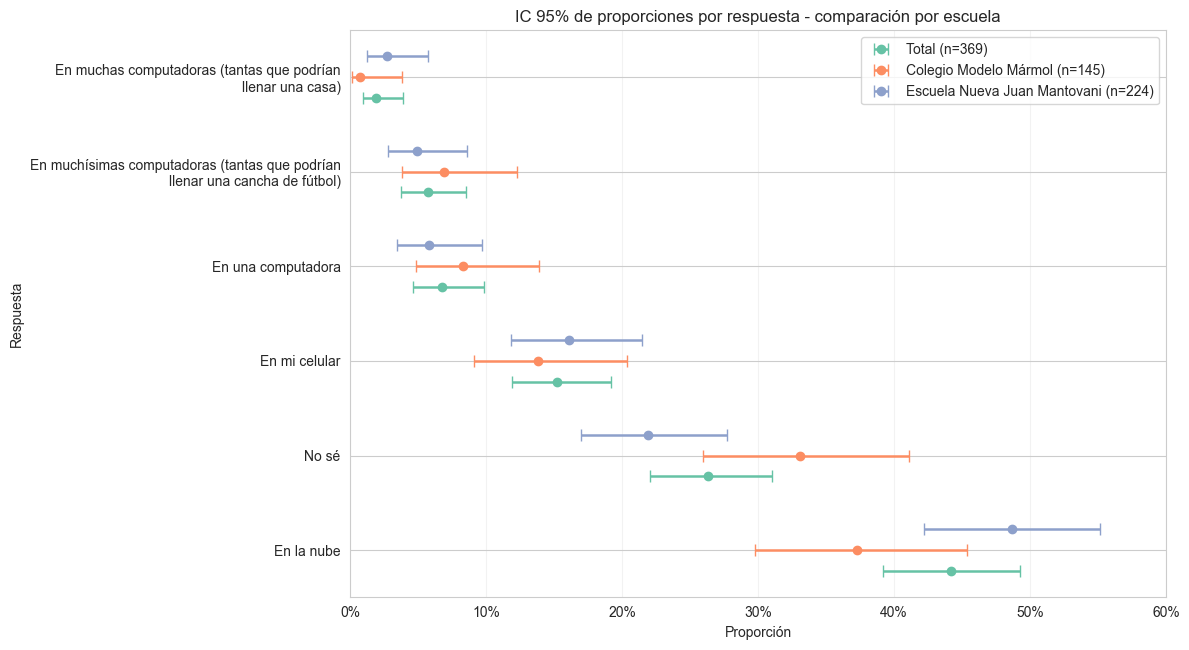

,Grupo,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Total,En la nube,163,44.2%,39.2%,49.3%,±5.0%
1,Total,No sé,97,26.3%,22.1%,31.0%,±4.5%
2,Total,En mi celular,56,15.2%,11.9%,19.2%,±3.7%
3,Total,En una computadora,25,6.8%,4.6%,9.8%,±2.6%
4,Total,En muchísimas computadoras (tantas que podrían...,21,5.7%,3.8%,8.5%,±2.4%
5,Total,En muchas computadoras (tantas que podrían lle...,7,1.9%,0.9%,3.9%,±1.5%
6,Colegio Modelo Mármol,En la nube,54,37.2%,29.8%,45.3%,±7.8%
7,Colegio Modelo Mármol,No sé,48,33.1%,26.0%,41.1%,±7.6%
8,Colegio Modelo Mármol,En mi celular,20,13.8%,9.1%,20.3%,±5.6%
9,Colegio Modelo Mármol,En una computadora,12,8.3%,4.8%,13.9%,±4.6%



Test Chi-cuadrado: Mármol vs Mantovani

Tabla de contingencia:


donde_youtube,En la nube,En mi celular,En muchas computadoras (tantas que podrían llenar una casa),En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol),En una computadora,No sé
escuela,,,,,,
Colegio Modelo Mármol,54,20,1,10,12,48
Escuela Nueva Juan Mantovani,109,36,6,11,13,49



χ² = 10.3607,  p-valor = 0.0656,  gl = 5
Cramér's V = 0.1676

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: pequeño (0.1 ≤ V < 0.3)


In [24]:
col = "donde_youtube"

print("INTERVALOS DE CONFIANZA (95%) - Por escuela")
print("="*60)

series_por_escuela = {
    "Total": df_fe[col],
    "Colegio Modelo Mármol": marmol[col],
    "Escuela Nueva Juan Mantovani": mantovani[col]
}

df_ic_escuela = graficar_intervalos_confianza_por_grupo(
    series_por_escuela,
    "IC 95% de proporciones por respuesta - comparación por escuela",
    archivo_salida=fig_name_prefix + '_ic_por_escuela' + file_ext
)

# Test Chi-cuadrado: Mármol vs Mantovani
test_chi2_y_cramers_v(df_fe, "escuela", col, "Mármol vs Mantovani");

## Intervalos de confianza y test de chi-cuadrado: por grado

INTERVALOS DE CONFIANZA (95%) - Por grado y escuela

--- Mármol ---


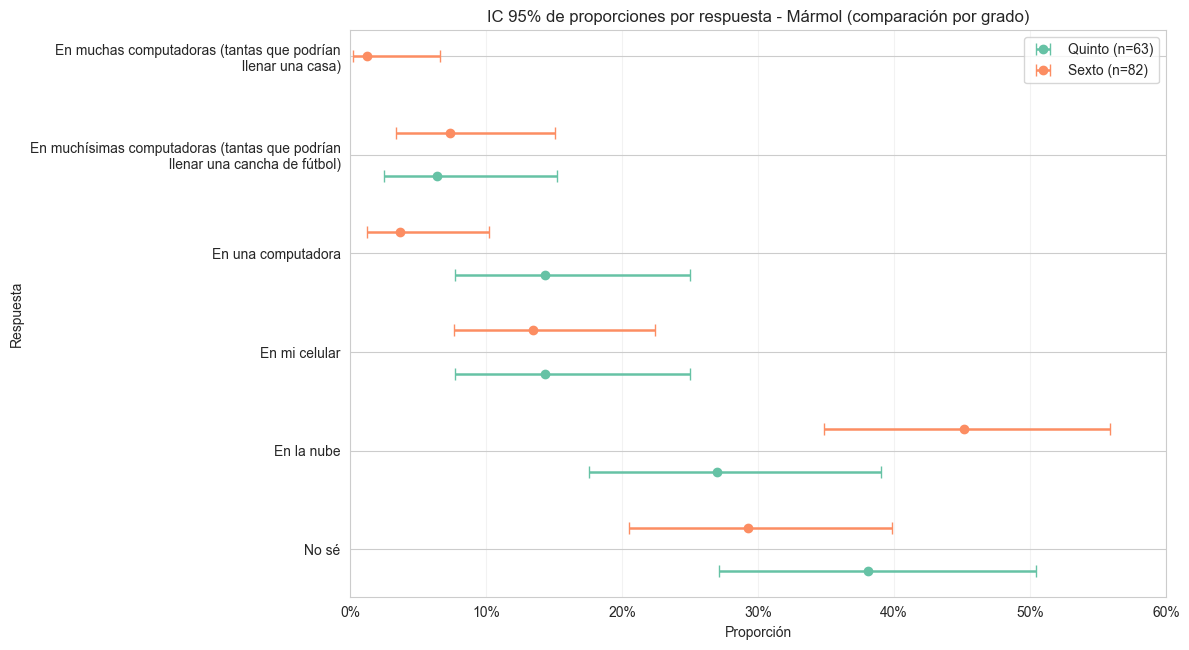

,Grupo,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Quinto,No sé,24,38.1%,27.1%,50.4%,±11.7%
1,Quinto,En la nube,17,27.0%,17.6%,39.0%,±10.7%
2,Quinto,En mi celular,9,14.3%,7.7%,25.0%,±8.6%
3,Quinto,En una computadora,9,14.3%,7.7%,25.0%,±8.6%
4,Quinto,En muchísimas computadoras (tantas que podrían...,4,6.3%,2.5%,15.2%,±6.4%
5,Quinto,En muchas computadoras (tantas que podrían lle...,0,0.0%,0.0%,5.7%,±2.9%
6,Sexto,No sé,24,29.3%,20.5%,39.9%,±9.7%
7,Sexto,En la nube,37,45.1%,34.8%,55.9%,±10.5%
8,Sexto,En mi celular,11,13.4%,7.7%,22.4%,±7.4%
9,Sexto,En una computadora,3,3.7%,1.3%,10.2%,±4.5%



--- Mantovani ---


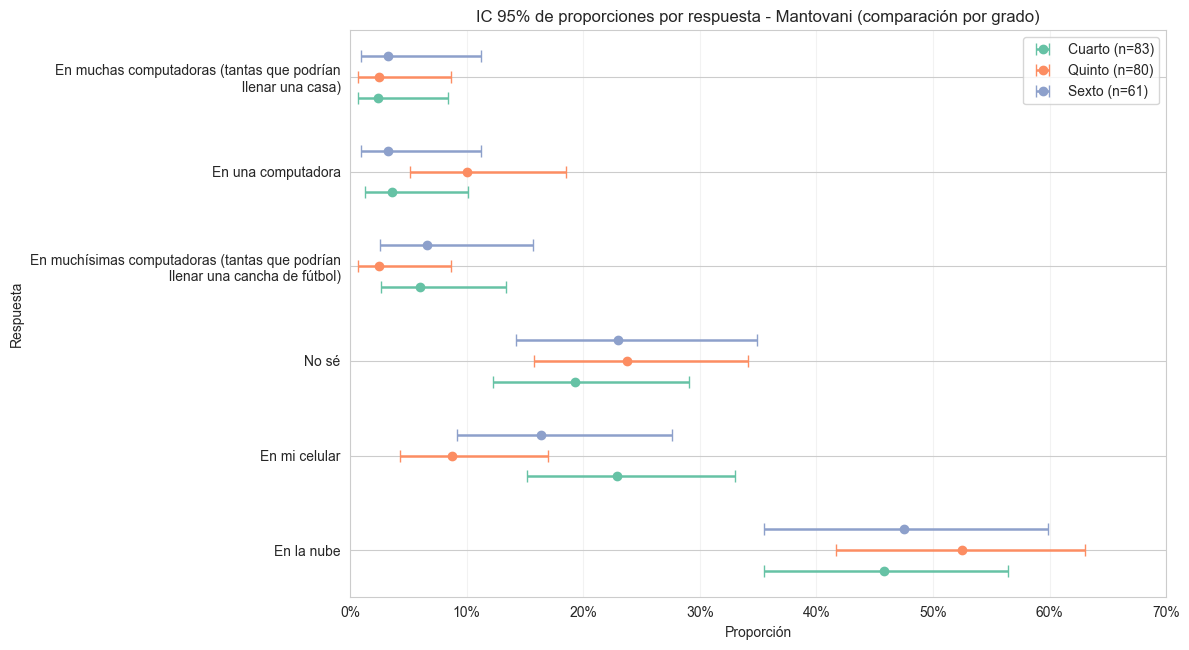

,Grupo,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Cuarto,En la nube,38,45.8%,35.5%,56.4%,±10.5%
1,Cuarto,En mi celular,19,22.9%,15.2%,33.0%,±8.9%
2,Cuarto,No sé,16,19.3%,12.2%,29.0%,±8.4%
3,Cuarto,En muchísimas computadoras (tantas que podrían...,5,6.0%,2.6%,13.3%,±5.4%
4,Cuarto,En una computadora,3,3.6%,1.2%,10.1%,±4.4%
5,Cuarto,En muchas computadoras (tantas que podrían lle...,2,2.4%,0.7%,8.4%,±3.9%
6,Quinto,En la nube,42,52.5%,41.7%,63.1%,±10.7%
7,Quinto,En mi celular,7,8.8%,4.3%,17.0%,±6.3%
8,Quinto,No sé,19,23.8%,15.8%,34.1%,±9.2%
9,Quinto,En muchísimas computadoras (tantas que podrían...,2,2.5%,0.7%,8.7%,±4.0%



Test Chi-cuadrado: Quinto vs Sexto (Mármol)

Tabla de contingencia:


donde_youtube,En la nube,En mi celular,En muchas computadoras (tantas que podrían llenar una casa),En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol),En una computadora,No sé
grado,,,,,,
Quinto,17,9,0,4,9,24
Sexto,37,11,1,6,3,24



χ² = 9.6840,  p-valor = 0.0847,  gl = 5
Cramér's V = 0.2584

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: pequeño (0.1 ≤ V < 0.3)

Test Chi-cuadrado: Cuarto vs Quinto vs Sexto (Mantovani)

Tabla de contingencia:


donde_youtube,En la nube,En mi celular,En muchas computadoras (tantas que podrían llenar una casa),En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol),En una computadora,No sé
grado,,,,,,
Cuarto,38,19,2,5,3,16
Quinto,42,7,2,2,8,19
Sexto,29,10,2,4,2,14



χ² = 11.2805,  p-valor = 0.3361,  gl = 10
Cramér's V = 0.1587

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: pequeño (0.1 ≤ V < 0.3)


In [25]:
col = "donde_youtube"

print("INTERVALOS DE CONFIANZA (95%) - Por grado y escuela")
print("="*60)

for escuela_nombre, escuela_df in [("Mármol", marmol), ("Mantovani", mantovani)]:
    series_por_grado = {
        grado: escuela_df[escuela_df['grado'] == grado][col]
        for grado in sorted(escuela_df['grado'].dropna().unique())
    }
    print(f"\n--- {escuela_nombre} ---")
    nombre_archivo = escuela_nombre.lower().replace("á", "a").replace(" ", "_")
    graficar_intervalos_confianza_por_grupo(
        series_por_grado,
        f"IC 95% de proporciones por respuesta - {escuela_nombre} (comparación por grado)",
        archivo_salida=fig_name_prefix + f'_ic_por_grado_{nombre_archivo}' + file_ext
    )

# Test Chi-cuadrado por grado dentro de cada escuela
test_chi2_y_cramers_v(marmol, "grado", col, "Quinto vs Sexto (Mármol)")
test_chi2_y_cramers_v(mantovani, "grado", col, "Cuarto vs Quinto vs Sexto (Mantovani)");

## Intervalos de confianza y test de chi-cuadrado: por género

INTERVALOS DE CONFIANZA (95%) - Por género y escuela

--- Mármol ---


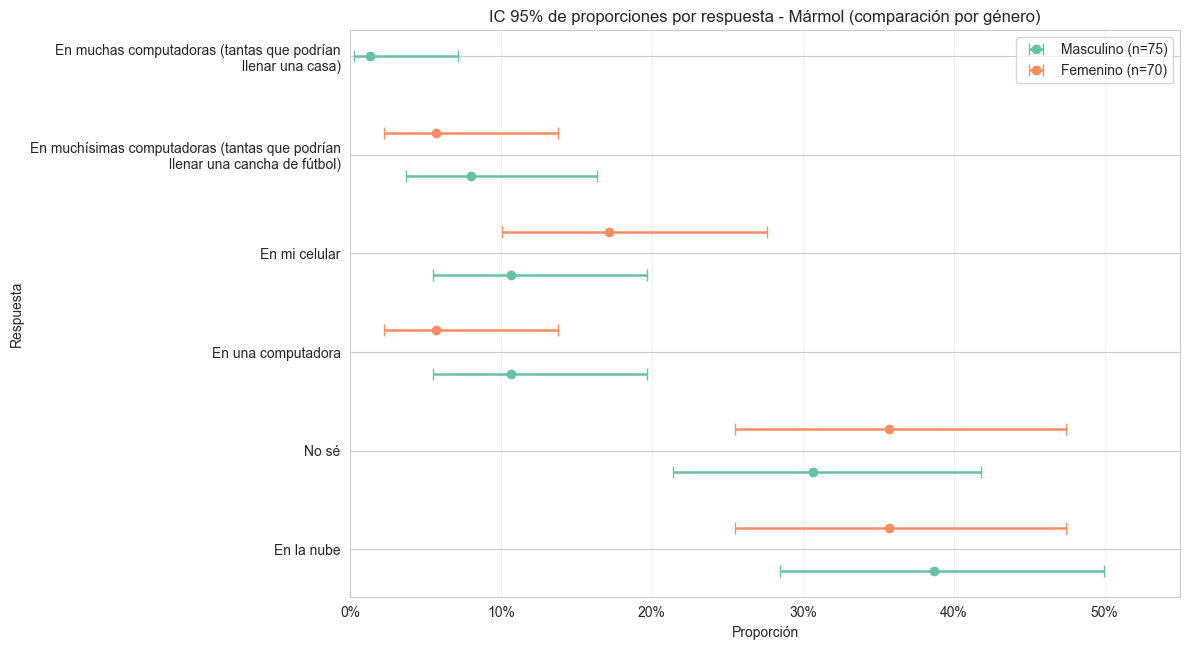

,Grupo,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Masculino,En la nube,29,38.7%,28.5%,50.0%,±10.8%
1,Masculino,No sé,23,30.7%,21.4%,41.8%,±10.2%
2,Masculino,En una computadora,8,10.7%,5.5%,19.7%,±7.1%
3,Masculino,En mi celular,8,10.7%,5.5%,19.7%,±7.1%
4,Masculino,En muchísimas computadoras (tantas que podrían...,6,8.0%,3.7%,16.4%,±6.3%
5,Masculino,En muchas computadoras (tantas que podrían lle...,1,1.3%,0.2%,7.2%,±3.5%
6,Femenino,En la nube,25,35.7%,25.5%,47.4%,±11.0%
7,Femenino,No sé,25,35.7%,25.5%,47.4%,±11.0%
8,Femenino,En una computadora,4,5.7%,2.2%,13.8%,±5.8%
9,Femenino,En mi celular,12,17.1%,10.1%,27.6%,±8.8%



--- Mantovani ---


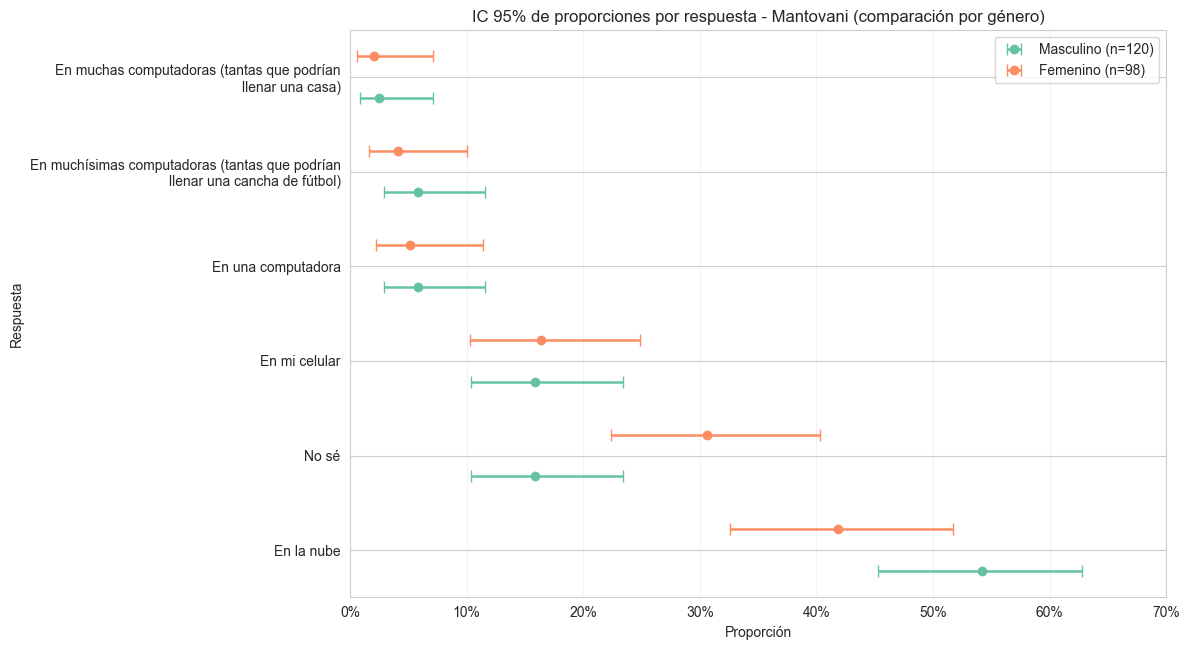

,Grupo,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Masculino,En la nube,65,54.2%,45.3%,62.8%,±8.8%
1,Masculino,No sé,19,15.8%,10.4%,23.4%,±6.5%
2,Masculino,En mi celular,19,15.8%,10.4%,23.4%,±6.5%
3,Masculino,En una computadora,7,5.8%,2.9%,11.6%,±4.3%
4,Masculino,En muchísimas computadoras (tantas que podrían...,7,5.8%,2.9%,11.6%,±4.3%
5,Masculino,En muchas computadoras (tantas que podrían lle...,3,2.5%,0.9%,7.1%,±3.1%
6,Femenino,En la nube,41,41.8%,32.6%,51.7%,±9.6%
7,Femenino,No sé,30,30.6%,22.4%,40.3%,±9.0%
8,Femenino,En mi celular,16,16.3%,10.3%,24.9%,±7.3%
9,Femenino,En una computadora,5,5.1%,2.2%,11.4%,±4.6%



Test Chi-cuadrado: Masculino vs Femenino (Mármol)

Tabla de contingencia:


donde_youtube,En la nube,En mi celular,En muchas computadoras (tantas que podrían llenar una casa),En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol),En una computadora,No sé
genero,,,,,,
Femenino,25,12,0,4,4,25
Masculino,29,8,1,6,8,23



χ² = 3.7450,  p-valor = 0.5867,  gl = 5
Cramér's V = 0.1607

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: pequeño (0.1 ≤ V < 0.3)

Test Chi-cuadrado: Masculino vs Femenino (Mantovani)

Tabla de contingencia:


donde_youtube,En la nube,En mi celular,En muchas computadoras (tantas que podrían llenar una casa),En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol),En una computadora,No sé
genero,,,,,,
Femenino,41,16,2,4,5,30
Masculino,65,19,3,7,7,19



χ² = 7.3669,  p-valor = 0.1948,  gl = 5
Cramér's V = 0.1838

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: pequeño (0.1 ≤ V < 0.3)


In [26]:
col = "donde_youtube"

print("INTERVALOS DE CONFIANZA (95%) - Por género y escuela")
print("="*60)

for escuela_nombre, escuela_df in [("Mármol", marmol), ("Mantovani", mantovani)]:
    series_por_genero = {
        genero: escuela_df[escuela_df['genero'] == genero][col]
        for genero in ["Masculino", "Femenino"]
        if len(escuela_df[escuela_df['genero'] == genero]) > 0
    }
    print(f"\n--- {escuela_nombre} ---")
    nombre_archivo = escuela_nombre.lower().replace("á", "a").replace(" ", "_")
    graficar_intervalos_confianza_por_grupo(
        series_por_genero,
        f"IC 95% de proporciones por respuesta - {escuela_nombre} (comparación por género)",
        archivo_salida=fig_name_prefix + f'_ic_por_genero_{nombre_archivo}' + file_ext
    )

# Test Chi-cuadrado por género dentro de cada escuela (excluyendo "Otro" por n muy bajo)
df_marmol_mf = marmol[marmol['genero'].isin(["Masculino", "Femenino"])]
test_chi2_y_cramers_v(df_marmol_mf, "genero", col, "Masculino vs Femenino (Mármol)")

df_mantovani_mf = mantovani[mantovani['genero'].isin(["Masculino", "Femenino"])]
test_chi2_y_cramers_v(df_mantovani_mf, "genero", col, "Masculino vs Femenino (Mantovani)");